# BiLSTM-CNN Baseline ABSA — Vietnamese Student Feedback
Kiến trúc: `Embedding → BiLSTM → CNN (kernel 2,3,4) → MaxPool → FC → Output (11 aspects × 4 classes)`

Baseline tái hiện theo paper gốc để so sánh với mBERT/PhoBERT Multi-task.

- **Label**: 4 class per aspect: `none(0) / positive(1) / neutral(2) / negative(3)`
- **Loss**: `CrossEntropyLoss` — không dùng IGNORE_INDEX
- **Không dùng BERT** — dùng vocabulary tự build + word embedding 300d


In [61]:
 #!pip install pyvi tensorboardX tqdm -q
!pip install underthesea tensorboardX tqdm -q

In [62]:
import os, sys, random, unicodedata, re
from google.colab import drive
drive.mount('/content/drive')
BASE_DIR = '/content/drive/MyDrive/bilstm'


# Gộp toàn bộ 16k từ tất cả các file
all_data_files = [f'{BASE_DIR}/train{i}.csv' for i in range(1, 7)]
all_data_files += [f'{BASE_DIR}/validation.csv', f'{BASE_DIR}/test.csv']

OUTPUT_DIR = f'{BASE_DIR}/a'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Seeds để thử
SEED_LIST = [42, 0, 123, 2024, 7]




# train1     = f'{BASE_DIR}/train1.csv'
# train2     = f'{BASE_DIR}/train2.csv'
# train3     = f'{BASE_DIR}/train3.csv'
# train4     = f'{BASE_DIR}/train4.csv'
# train5     = f'{BASE_DIR}/train5.csv'
# train6     = f'{BASE_DIR}/train6.csv'
# validation = f'{BASE_DIR}/validation.csv'
# test       = f'{BASE_DIR}/test.csv'

# train_paper      = f'{BASE_DIR}/train_paper.csv'
# validation_paper = f'{BASE_DIR}/validation_paper.csv'
# test_paper       = f'{BASE_DIR}/test_paper.csv'





Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Config

In [63]:
import os, sys, random, unicodedata, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from torch.optim import Adam
from tensorboardX import SummaryWriter
from tqdm.notebook import tqdm, trange
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from collections import Counter
#from pyvi import ViTokenizer
from underthesea import word_tokenize

# ON_KAGGLE   = os.path.exists('/kaggle/working')
# WORKING_DIR = '/kaggle/working' if ON_KAGGLE else os.getcwd()
# print('Environment:', 'Kaggle' if ON_KAGGLE else 'Local')

# # ── Data paths (Paper-matched subset: ~5,286 pairs, 7:1:2 split) ─────────
# # Subset đã được lọc để khớp phân bố aspect-sentiment của paper gốc
# train_paper      = '/kaggle/input/datasets/conanwinner1/vku-feedback-5k/train_paper.csv'
# validation_paper = '/kaggle/input/datasets/conanwinner1/vku-feedback-5k/validation_paper.csv'
# test_paper       = '/kaggle/input/datasets/conanwinner1/vku-feedback-5k/test_paper.csv'

# OUTPUT_DIR = f'{WORKING_DIR}/bilstm-cnn-acsa'
# os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Aspect Categories (giữ đúng thứ tự như PhoBERT notebook) ─────────────
ASPECT_CATEGORIES = [
    'ky_nang_giang_day',    # 0
    'hanh_vi',              # 1
    'de_xuat',              # 2
    'bai_tap',              # 3
    'chuong_trinh_hoc',     # 4
    'kien_thuc',            # 5
    'kinh_nghiem',          # 6
    'cung_cap_tai_lieu',    # 7
    'thiet_bi_day_hoc',     # 8
    'cham_diem',            # 9
    'noi_chung',            # 10
]
NUM_ASPECTS = len(ASPECT_CATEGORIES)
ASPECT2ID   = {a: i for i, a in enumerate(ASPECT_CATEGORIES)}

# ── Label mapping (4 class per aspect) ───────────────────────────────────
# none=0, positive=1, neutral=2, negative=3
LABEL_MAP = {'none': 0, 'positive': 1, 'neutral': 2, 'negative': 3}
ID2LABEL  = {v: k for k, v in LABEL_MAP.items()}
NUM_CLASSES = len(LABEL_MAP)

# Mapping từ sentiment string trong CSV → label mới
# CSV: negative=0, neutral=1, positive=2  →  none=0, pos=1, neu=2, neg=3
SENTIMENT_STR_TO_LABEL = {
    'positive': 1,
    'neutral':  2,
    'negative': 3,
}

# ── Model hyperparams (theo paper) ───────────────────────────────────────
EMBEDDING_DIM  = 300
HIDDEN_SIZE    = 128
NUM_FILTERS    = 128
KERNEL_SIZES   = [2, 3, 4]
FC_HIDDEN      = 128
DROPOUT        = 0.6

# ── Training ──────────────────────────────────────────────────────────────
SEED             = 42
MAX_EPOCHS       = 35
TRAIN_BATCH_SIZE = 32
EVAL_BATCH_SIZE  = 64
LEARNING_RATE    = 5e-4
WEIGHT_DECAY     = 1e-3
MAX_SEQ_LENGTH   = 128
PATIENCE         = 5

# ── Logging ───────────────────────────────────────────────────────────────
LOG_STEPS  = 50

print(f'Aspects   : {NUM_ASPECTS}')
print(f'Classes   : {NUM_CLASSES} (none/positive/neutral/negative)')
print(f'Output    : {OUTPUT_DIR}')


Aspects   : 11
Classes   : 4 (none/positive/neutral/negative)
Output    : /content/drive/MyDrive/bilstm/a


## 2. Kiểm tra GPU

In [64]:
print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_gpu  = torch.cuda.device_count()


PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


## 3. Preprocessing & Vocabulary

In [65]:
def preprocess_text(text):
    text = unicodedata.normalize('NFC', str(text).strip())
    text = re.sub(r'^[\s\.\-]+', '', text)
    text = word_tokenize(text, format='text')
    return text.lower()


# Test
for s in ['Giảng viên rất nhiệt tình.', '. Thầy/cô tôn trọng sinh viên.']:
    print(f'  {s}  →  {preprocess_text(s)}')

  Giảng viên rất nhiệt tình.  →  giảng_viên rất nhiệt_tình .
  . Thầy/cô tôn trọng sinh viên.  →  thầy / cô tôn_trọng sinh_viên .


## 4. Load Data & Build Vocabulary

In [66]:
from collections import Counter

def load_bilstm_data(df_file):
    """
    Group theo id → mỗi sample:
      - tokens : list[str] (đã preprocess)
      - labels : list[int] length=NUM_ASPECTS, giá trị 0-3
                 0=none, 1=positive, 2=neutral, 3=negative
    """
    df = df_file
    samples = []
    skipped = 0

    for sent_id, group in df.groupby('id'):
        text   = preprocess_text(group.iloc[0]['text'])
        tokens = text.split()

        labels = [0] * NUM_ASPECTS   # mặc định none=0

        for _, row in group.iterrows():
            asp_str = str(row['aspect']).strip()
            sen_str = str(row['sentiment']).strip()

            if asp_str not in ASPECT2ID:
                skipped += 1
                continue
            if sen_str not in SENTIMENT_STR_TO_LABEL:
                skipped += 1
                continue

            asp_idx = ASPECT2ID[asp_str]
            labels[asp_idx] = SENTIMENT_STR_TO_LABEL[sen_str]

        samples.append({'tokens': tokens, 'labels': labels})

    if skipped:
        print(f'  ⚠️  Skipped {skipped} rows')
    return samples


def build_vocab(samples, min_freq=1):
    """Build word2idx từ train set."""
    counter = Counter()
    for s in samples:
        counter.update(s['tokens'])
    word2idx = {'<PAD>': 0, '<UNK>': 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            word2idx[word] = len(word2idx)
    return word2idx


def print_stats(samples, split_name):
    print(f'\n  {split_name}: {len(samples)} sentences')
    aspect_counts = [0] * NUM_ASPECTS
    label_counts  = Counter()
    for s in samples:
        for i, lbl in enumerate(s['labels']):
            if lbl != 0:
                aspect_counts[i] += 1
                label_counts[ID2LABEL[lbl]] += 1
    print('  Aspect distribution (non-none):')
    max_cnt = max(aspect_counts) or 1
    for i, cat in enumerate(ASPECT_CATEGORIES):
        bar = '█' * int(20 * aspect_counts[i] / max_cnt)
        print(f'    {i:2d}. {cat:<25s} {aspect_counts[i]:4d}  {bar}')
    print('  Label distribution:', dict(label_counts))



# Các biến dev_s, test_s, word2idx sẽ được tạo ở cell sample bên dưới
print("Sẵn sàng load data.")


Sẵn sàng load data.


In [67]:

def verify_distribution(samples, label=''):
    asp_counts = {asp: 0 for asp in ASPECT_CATEGORIES}
    for s in samples:
        for i, lbl in enumerate(s['labels']):
            if lbl != 0:
                asp_counts[ASPECT_CATEGORIES[i]] += 1
    total = sum(asp_counts.values())
    print(f"\n{label}: {len(samples)} câu | {total} labels")
    print(f"{'Aspect':<25} {'Count':>6} {'Ratio%':>7}")
    print("-" * 42)
    for asp in ASPECT_CATEGORIES:
        cnt = asp_counts[asp]
        ratio = cnt / total * 100 if total > 0 else 0
        print(f"{asp:<25} {cnt:>6} {ratio:>6.1f}%")



_dfs = []
for i in range(1, 7):
    _df = pd.read_csv(f'{BASE_DIR}/train{i}.csv')
    _df['id'] = i * 100000 + _df['id']
    _dfs.append(_df)
df_train_fixed = pd.concat(_dfs, ignore_index=True)

# Val/Test ID cũng cần unique nếu có thể trùng với train
df_val_fixed  = pd.read_csv(f'{BASE_DIR}/validation.csv')
df_val_fixed['id'] = 7 * 100000 + df_val_fixed['id']

df_test_fixed = pd.read_csv(f'{BASE_DIR}/test.csv')
df_test_fixed['id'] = 8 * 100000 + df_test_fixed['id']


print(f"Train: {df_train_fixed['id'].nunique()} câu")
print(f"Val  : {df_val_fixed['id'].nunique()} câu")
print(f"Test : {df_test_fixed['id'].nunique()} câu")
print(f"Tổng : {df_train_fixed['id'].nunique() + df_val_fixed['id'].nunique() + df_test_fixed['id'].nunique()} câu")

# Load thành samples
dev_s  = load_bilstm_data(df_val_fixed)
test_s = load_bilstm_data(df_test_fixed)

# Build vocab tạm
word2idx = build_vocab(dev_s + test_s, min_freq=1)
VOCAB_SIZE = len(word2idx)
print(f"\nTemp vocab: {VOCAB_SIZE}")

verify_distribution(dev_s,  'Val')
verify_distribution(test_s, 'Test')

Train: 11389 câu
Val  : 1575 câu
Test : 3160 câu
Tổng : 16124 câu

Temp vocab: 2557

Val: 1575 câu | 2312 labels
Aspect                     Count  Ratio%
------------------------------------------
ky_nang_giang_day            624   27.0%
hanh_vi                      608   26.3%
de_xuat                      278   12.0%
bai_tap                      154    6.7%
chuong_trinh_hoc             144    6.2%
kien_thuc                    105    4.5%
kinh_nghiem                   88    3.8%
cung_cap_tai_lieu             90    3.9%
thiet_bi_day_hoc              81    3.5%
cham_diem                     43    1.9%
noi_chung                     97    4.2%

Test: 3160 câu | 4664 labels
Aspect                     Count  Ratio%
------------------------------------------
ky_nang_giang_day           1314   28.2%
hanh_vi                     1209   25.9%
de_xuat                      549   11.8%
bai_tap                      330    7.1%
chuong_trinh_hoc             272    5.8%
kien_thuc                    238 

## 4.1. Load Pretrained Word Embedding (fastText Vietnamese)

In [68]:
!pip install gensim
# ── Load Word2VecVN (Tiếng Việt) ──────────────────────────────────────────
# Tải model từ: https://github.com/sonvx/word2vecVN
# Upload file .bin (ví dụ: baomoi.window2.vn.model.bin) lên Kaggle dataset.

import os
from gensim.models import KeyedVectors
import numpy as np

# Đổi tên file ở đây cho đúng với file bạn upload lên Kaggle
#WORD2VEC_VN_PATH = '/kaggle/input/models/conanwinner1/w2vec/pytorch/default/1/baomoi.vn.model.bin'

WORD2VEC_VN_PATH = '/content/drive/MyDrive/bilstm/baomoi.vn.model.bin'

def load_word2vec_embeddings(word2idx, embedding_dim=300, model_path=''):
    """
    Load pre-trained Word2Vec model (gensim) từ file .bin hoặc .vec.
    Hỗ trợ xử lý từ ghép (compound words) tiếng Việt.
    """
    vocab_size = len(word2idx)
    embedding_matrix = np.random.uniform(-0.1, 0.1, (vocab_size, embedding_dim)).astype(np.float32)
    embedding_matrix[0] = 0.0   # <PAD> = zero vector

    try:
        print(f"Loading Word2Vec model from: {model_path} ...")
        if model_path.endswith('.bin'):
            # Load binary format
            w2v_model = KeyedVectors.load_word2vec_format(model_path, binary=True)
        else:
            # Load text format (.vec / .txt)
            w2v_model = KeyedVectors.load_word2vec_format(model_path, binary=False)

        # Kiểm tra xem dimension của model có khớp không
        actual_dim = w2v_model.vector_size
        if actual_dim != embedding_dim:
            print(f"⚠️ Cảnh báo: Model dimension ({actual_dim}) khác với cấu hình ({embedding_dim}).")
            print("→ Đang tự động điều chỉnh EMBEDDING_DIM...")
            embedding_matrix = np.random.uniform(-0.1, 0.1, (vocab_size, actual_dim)).astype(np.float32)
            embedding_matrix[0] = 0.0
            embedding_dim = actual_dim

        found = 0
        found_subword = 0

        for word, idx in word2idx.items():
            if word in ('<PAD>', '<UNK>'):
                continue

            # Exact match
            if word in w2v_model:
                embedding_matrix[idx] = w2v_model[word]
                found += 1
            # Xử lý từ ghép tiếng Việt (VD: "giảng_viên" -> trung bình "giảng" và "viên")
            elif '_' in word:
                subwords = word.split('_')
                sub_vecs = [w2v_model[sw] for sw in subwords if sw in w2v_model]
                if sub_vecs:
                    embedding_matrix[idx] = np.mean(sub_vecs, axis=0)
                    found_subword += 1

        total_found = found + found_subword
        coverage = total_found / (vocab_size - 2) * 100
        print(f"  Exact match: {found} words")
        print(f"  Sub-word avg match: {found_subword} words")
        print(f"  Coverage: {total_found}/{vocab_size-2} words ({coverage:.1f}%)")
        print("✓ Successfully loaded pre-trained Word2Vec embeddings")

    except Exception as e:
        print(f"⚠️ Error loading Word2Vec: {e}")
        print("⚠️ Using random init embeddings instead.")

    return np.array(embedding_matrix, dtype=np.float32), embedding_dim

if os.path.exists(WORD2VEC_VN_PATH):
    pretrained_embeddings = load_word2vec_embeddings(word2idx, EMBEDDING_DIM, WORD2VEC_VN_PATH)
else:
    print(f"⚠️ Không tìm thấy file {WORD2VEC_VN_PATH}")
    print("⚠️ Chuyển sang dùng random embeddings.")
    pretrained_embeddings = None


Loading Word2Vec model from: /content/drive/MyDrive/bilstm/baomoi.vn.model.bin ...
  Exact match: 2134 words
  Sub-word avg match: 232 words
  Coverage: 2366/2555 words (92.6%)
✓ Successfully loaded pre-trained Word2Vec embeddings


## 5. Dataset & DataLoader

In [69]:
class BiLSTMDataset(Dataset):
    def __init__(self, samples, word2idx, max_len):
        self.samples  = samples
        self.word2idx = word2idx
        self.max_len  = max_len
        self.unk_idx  = word2idx.get('<UNK>', 1)
        self.pad_idx  = word2idx.get('<PAD>', 0)

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s      = self.samples[idx]
        tokens = s['tokens']
        ids    = [self.word2idx.get(t, self.unk_idx) for t in tokens]

        # Truncate
        ids = ids[:self.max_len]
        # Pad
        ids = ids + [self.pad_idx] * (self.max_len - len(ids))

        return {
            'input_ids': torch.tensor(ids,          dtype=torch.long),
            'labels':    torch.tensor(s['labels'],  dtype=torch.long),
        }
pass


## 6. Model — BiLSTM-CNN

In [70]:
from sklearn.utils.class_weight import compute_class_weight

class FocalLoss(nn.Module):
    """
    Focal Loss: giảm contribution của easy examples (none dễ predict đúng)
    → model tập trung vào hard examples (non-none).
    gamma=2 là giá trị chuẩn từ paper gốc Focal Loss.
    """
    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma  = gamma

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        pt      = torch.exp(-ce_loss)
        focal   = (1 - pt) ** self.gamma * ce_loss
        return focal.mean()


class BiLSTMCNN_ABSA(nn.Module):
    """
    Embedding(300) → BiLSTM(128×2=256) → CNN(k=2,3,4, 128 filters each)
    → GlobalMaxPool → Concat(384) → FC(128) → Output(11×4)

    Sử dụng per-aspect weighted CrossEntropyLoss để xử lý class imbalance.
    """
    def __init__(self, vocab_size, embedding_dim=300, hidden_size=128,
                 num_aspects=11, num_classes=4, num_filters=128,
                 kernel_sizes=(2,3,4), fc_hidden=128, dropout=0.5,
                 pretrained_embeddings=None, padding_idx=0,
                 aspect_class_weights=None):
        super().__init__()
        self.num_aspects = num_aspects
        self.num_classes = num_classes

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)

        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(
                torch.from_numpy(np.array(pretrained_embeddings, dtype=np.float32))
            )
            self.embedding.weight.data[padding_idx] = 0.0  # PAD = zero

        self.bilstm = nn.LSTM(
            input_size=embedding_dim, hidden_size=hidden_size,
            batch_first=True, bidirectional=True,

        )
        lstm_out_dim = hidden_size * 2   # 256

        self.convs = nn.ModuleList([
            nn.Conv1d(lstm_out_dim, num_filters, kernel_size=k)
            for k in kernel_sizes
        ])

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(num_filters * len(kernel_sizes), fc_hidden)
        self.output  = nn.Linear(fc_hidden, num_aspects * num_classes)

        self.loss_fns = nn.ModuleList()
        if aspect_class_weights is not None:
            for w in aspect_class_weights:
                self.loss_fns.append(nn.CrossEntropyLoss(weight=w))
        else:
            for _ in range(num_aspects):
                self.loss_fns.append(nn.CrossEntropyLoss())

    def forward(self, input_ids, labels=None):
        emb      = self.embedding(input_ids)          # (B, L, 300)
        lstm_out, _ = self.bilstm(emb)                # (B, L, 256)
        x        = lstm_out.transpose(1, 2)           # (B, 256, L)

        pooled = []
        for conv in self.convs:
            c = F.relu(conv(x))                       # (B, 128, L-k+1)
            p = F.max_pool1d(c, c.size(2)).squeeze(2) # (B, 128)
            pooled.append(p)

        x = torch.cat(pooled, dim=1)                  # (B, 384)
        x = self.dropout(x)
        x = F.relu(self.fc(x))                        # (B, 128)
        x = self.dropout(x)
        logits = self.output(x)                       # (B, 44)
        logits = logits.view(-1, self.num_aspects, self.num_classes)  # (B, 11, 4)

        loss = None
        if labels is not None:
            total_loss = 0.0
            for asp_idx in range(self.num_aspects):
                asp_logits = logits[:, asp_idx, :]    # (B, 4)
                asp_labels = labels[:, asp_idx]       # (B,)
                total_loss += self.loss_fns[asp_idx](asp_logits, asp_labels)
            loss = total_loss / self.num_aspects
        return loss, logits



def compute_aspect_class_weights(train_samples, num_aspects=11, num_classes=4):
    counts = np.zeros((num_aspects, num_classes), dtype=np.float64)
    for s in train_samples:
        for i, lbl in enumerate(s['labels']):
            counts[i, lbl] += 1.0

    weights_list = []
    for i in range(num_aspects):
        total = counts[i].sum()
        w = np.zeros(num_classes)
        for c in range(num_classes):
            if counts[i, c] > 0:
                w[c] = np.sqrt(total / (num_classes * counts[i, c]))
            else:
                w[c] = 1.0
        weights_list.append(torch.tensor(w, dtype=torch.float))

        asp_name = ASPECT_CATEGORIES[i] if i < len(ASPECT_CATEGORIES) else f"asp_{i}"
        none_pct = counts[i, 0] / total * 100
        print(f"  {asp_name:<25s} none={counts[i,0]:5.0f}({none_pct:5.1f}%) "
              f"pos={counts[i,1]:4.0f} neu={counts[i,2]:4.0f} neg={counts[i,3]:4.0f} "
              f"→ weights=[{w[0]:.2f}, {w[1]:.2f}, {w[2]:.2f}, {w[3]:.2f}]")

    return weights_list


def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

set_seed(SEED)



## 7. Training

In [71]:
def evaluate_model(model, loader):
    model.eval()
    total_loss = 0.0
    all_gold, all_pred = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating', leave=False):
            input_ids = batch['input_ids'].to(device)
            labels    = batch['labels'].to(device)

            loss, logits = model(input_ids, labels)
            if n_gpu > 1: loss = loss.mean()
            total_loss += loss.item()

            pred = logits.argmax(dim=-1).cpu().numpy()   # (B, 11)
            gold = labels.cpu().numpy()                  # (B, 11)
            all_gold.append(gold)
            all_pred.append(pred)

    all_gold = np.vstack(all_gold)   # (N, 11)
    all_pred = np.vstack(all_pred)

    # Aspect Detection: pred!=0 → aspect present
    asp_gold = (all_gold != 0).astype(int)
    asp_pred = (all_pred != 0).astype(int)
    asp_f1_micro = f1_score(asp_gold, asp_pred, average='micro', zero_division=0)
    asp_f1_macro = f1_score(asp_gold, asp_pred, average='macro', zero_division=0)

    # Aspect-Sentiment: chỉ tính ở vị trí gold != 0
    # Joint evaluation: đúng khi gold!=0 VÀ pred==gold
    tp_as = fp_as = fn_as = 0
    for i in range(all_gold.shape[0]):
        for j in range(all_gold.shape[1]):
            y, p = int(all_gold[i, j]), int(all_pred[i, j])
            if y != 0 and p == y: tp_as += 1
            if y != 0 and p != y: fn_as += 1
            if p != 0 and p != y: fp_as += 1

    prec_as  = tp_as / (tp_as + fp_as) if (tp_as + fp_as) > 0 else 0
    rec_as   = tp_as / (tp_as + fn_as) if (tp_as + fn_as) > 0 else 0
    sent_f1_micro = 2 * prec_as * rec_as / (prec_as + rec_as) if (prec_as + rec_as) > 0 else 0
    sent_f1_macro = sent_f1_micro  # dùng micro cho early stopping (đúng paper)

    # Giữ lại để dùng cho classification_report nếu cần
    mask = all_gold != 0
    sent_gold = all_gold[mask].tolist()
    sent_pred = all_pred[mask].tolist()

    return {
        'loss':          total_loss / len(loader),
        'asp_f1_micro':  asp_f1_micro,
        'asp_f1_macro':  asp_f1_macro,
        'sent_f1_micro': sent_f1_micro,
        'sent_f1_macro': sent_f1_macro,
        'all_gold':      all_gold,
        'all_pred':      all_pred,
        'sent_gold':     sent_gold,
        'sent_pred':     sent_pred,
    }


In [72]:
from copy import deepcopy

def run_one_seed(seed, df_train, dev_s, test_s):
    print(f"\n{'='*60}")
    print(f"SEED = {seed}")
    print(f"{'='*60}")
    history = {'epoch': [], 'train_loss': [], 'val_loss': [],
           'val_asp_f1_micro': [], 'val_asp_f1_macro': [],
           'val_sent_f1_micro': [], 'val_sent_f1_macro': []}
    # 1. Load data — cố định toàn bộ 16k

    train_s_seed = load_bilstm_data(df_train)
    dev_s_seed   = dev_s
    test_s_seed  = test_s
    verify_distribution(train_s_seed, f'Train seed={seed}')
    print(f"Train: {len(train_s_seed)} | Val: {len(dev_s_seed)} | Test: {len(test_s_seed)}")




    # 2. Build vocab + embedding
    word2idx_seed = build_vocab(train_s_seed, min_freq=1)
    vocab_size_seed = len(word2idx_seed)
    emb_matrix, emb_dim = load_word2vec_embeddings(word2idx_seed, EMBEDDING_DIM, WORD2VEC_VN_PATH)

    # 3. Dataset & Loader
    train_dataset = BiLSTMDataset(train_s_seed, word2idx_seed, MAX_SEQ_LENGTH)
    dev_dataset   = BiLSTMDataset(dev_s_seed,   word2idx_seed, MAX_SEQ_LENGTH)
    test_dataset  = BiLSTMDataset(test_s_seed,  word2idx_seed, MAX_SEQ_LENGTH)

    train_loader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset),
                              batch_size=TRAIN_BATCH_SIZE)
    dev_loader   = DataLoader(dev_dataset,   sampler=SequentialSampler(dev_dataset),
                              batch_size=EVAL_BATCH_SIZE)
    test_loader  = DataLoader(test_dataset,  sampler=SequentialSampler(test_dataset),
                              batch_size=EVAL_BATCH_SIZE)

    # 4. Model
    set_seed(seed)
    print("  Computing class weights...")
    aspect_weights_raw = compute_aspect_class_weights(
        train_s_seed,
    )
    aspect_weights_device = [w.to(device) for w in aspect_weights_raw]

    m = BiLSTMCNN_ABSA(
        vocab_size=vocab_size_seed, embedding_dim=emb_dim,
        hidden_size=HIDDEN_SIZE, num_aspects=NUM_ASPECTS, num_classes=NUM_CLASSES,
        num_filters=NUM_FILTERS, kernel_sizes=KERNEL_SIZES,
        fc_hidden=FC_HIDDEN, dropout=DROPOUT,
        pretrained_embeddings=emb_matrix,
        aspect_class_weights=aspect_weights_device,
    ).to(device)



    optimizer = Adam(m.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)  # THÊM DÒNG NÀY
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2, min_lr=1e-5
    )

    best_val_f1  = 0.0
    patience_cnt = 0
    best_state   = None

    for epoch in range(MAX_EPOCHS):


        m.train()
        epoch_loss = 0.0
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            labels    = batch['labels'].to(device)
            optimizer.zero_grad()
            loss, _   = m(input_ids, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()

        val_metrics = evaluate_model(m, dev_loader)
        # Tính F1 cân bằng hơn: phạt nếu precision quá thấp so với recall
        p = val_metrics.get('asp_prec', val_metrics['asp_f1_micro'])
        r = val_metrics['asp_f1_micro']
        scheduler.step(val_metrics['asp_f1_micro'])
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(epoch_loss / len(train_loader))
        history['val_loss'].append(val_metrics['loss'])
        history['val_asp_f1_micro'].append(val_metrics['asp_f1_micro'])
        history['val_asp_f1_macro'].append(val_metrics['asp_f1_macro'])
        history['val_sent_f1_micro'].append(val_metrics['sent_f1_micro'])
        history['val_sent_f1_macro'].append(val_metrics['sent_f1_macro'])

        print(f"  [E{epoch+1:02d}] loss={epoch_loss/len(train_loader):.4f} "
              f"| asp_f1={val_metrics['asp_f1_micro']:.4f} "
              f"| sent_f1={val_metrics['sent_f1_micro']:.4f}")

        if val_metrics['asp_f1_micro'] > best_val_f1:
            best_val_f1 = val_metrics['asp_f1_micro']
            patience_cnt = 0
            best_state = deepcopy(m.state_dict())
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    # Load best và evaluate test
    m.load_state_dict(best_state)
    test_metrics = evaluate_model(m, test_loader)

    print(f"\n  SEED {seed} RESULT:")
    print(f"  asp_f1_micro  = {test_metrics['asp_f1_micro']:.4f}")
    print(f"  sent_f1_micro = {test_metrics['sent_f1_micro']:.4f}")

    return test_metrics, m, word2idx_seed, history, dev_s_seed, test_s_seed


# ── Chạy single seed (16k dataset cố định) ───────────────────────────────
metrics, model, word2idx, history, dev_s_final, test_s_final = run_one_seed(
    SEED, df_train_fixed, dev_s, test_s
)



# Recreate loaders với word2idx đúng
dev_dataset_best  = BiLSTMDataset(dev_s_final,  word2idx, MAX_SEQ_LENGTH)
test_dataset_best = BiLSTMDataset(test_s_final, word2idx, MAX_SEQ_LENGTH)
dev_loader  = DataLoader(dev_dataset_best,  sampler=SequentialSampler(dev_dataset_best),  batch_size=EVAL_BATCH_SIZE)
test_loader = DataLoader(test_dataset_best, sampler=SequentialSampler(test_dataset_best), batch_size=EVAL_BATCH_SIZE)
print(f"Dev: {len(dev_dataset_best)} | Test: {len(test_dataset_best)}")


SEED = 42

Train seed=42: 11389 câu | 16883 labels
Aspect                     Count  Ratio%
------------------------------------------
ky_nang_giang_day           4546   26.9%
hanh_vi                     4474   26.5%
de_xuat                     2044   12.1%
bai_tap                     1241    7.4%
chuong_trinh_hoc             989    5.9%
kien_thuc                    867    5.1%
kinh_nghiem                  652    3.9%
cung_cap_tai_lieu            646    3.8%
thiet_bi_day_hoc             564    3.3%
cham_diem                    314    1.9%
noi_chung                    546    3.2%
Train: 11389 | Val: 1575 | Test: 3160
Loading Word2Vec model from: /content/drive/MyDrive/bilstm/baomoi.vn.model.bin ...
  Exact match: 3078 words
  Sub-word avg match: 540 words
  Coverage: 3618/3995 words (90.6%)
✓ Successfully loaded pre-trained Word2Vec embeddings
  Computing class weights...
  ky_nang_giang_day         none= 6843( 60.1%) pos=2760 neu= 121 neg=1665 → weights=[0.65, 1.02, 4.85, 1.31]
  hanh

Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

  [E01] loss=0.8041 | asp_f1=0.6908 | sent_f1=0.6179


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

  [E02] loss=0.5791 | asp_f1=0.7410 | sent_f1=0.6654


...

  [E14] loss=0.3940 | asp_f1=0.8128 | sent_f1=0.7168


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

  [E15] loss=0.3862 | asp_f1=0.8084 | sent_f1=0.7140
  Early stopping at epoch 15


Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]


  SEED 42 RESULT:
  asp_f1_micro  = 0.8165
  sent_f1_micro = 0.7162
Dev: 1575 | Test: 3160


## 8. Evaluation

In [73]:
print('=== Dev ===')
dev_metrics = evaluate_model(model, dev_loader)
print(f"asp_f1_micro={dev_metrics['asp_f1_micro']:.4f} | asp_f1_macro={dev_metrics['asp_f1_macro']:.4f}")
print(f"sent_f1_micro={dev_metrics['sent_f1_micro']:.4f} | sent_f1_macro={dev_metrics['sent_f1_macro']:.4f}")

print('\n=== Test ===')
test_metrics = evaluate_model(model, test_loader)
print(f"asp_f1_micro={test_metrics['asp_f1_micro']:.4f} | asp_f1_macro={test_metrics['asp_f1_macro']:.4f}")
print(f"sent_f1_micro={test_metrics['sent_f1_micro']:.4f} | sent_f1_macro={test_metrics['sent_f1_macro']:.4f}")

print('\nPer-class Sentiment (Test, bỏ none):')
print(classification_report(
    test_metrics['sent_gold'], test_metrics['sent_pred'],
    labels=[1,2,3], target_names=['positive','neutral','negative'], zero_division=0))


=== Dev ===


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

asp_f1_micro=0.8152 | asp_f1_macro=0.7631
sent_f1_micro=0.7192 | sent_f1_macro=0.7192

=== Test ===


Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

asp_f1_micro=0.8165 | asp_f1_macro=0.7555
sent_f1_micro=0.7162 | sent_f1_macro=0.7162

Per-class Sentiment (Test, bỏ none):
              precision    recall  f1-score   support

    positive       0.96      0.80      0.87      2344
     neutral       0.66      0.59      0.62       691
    negative       0.86      0.68      0.76      1629

   micro avg       0.88      0.73      0.79      4664
   macro avg       0.83      0.69      0.75      4664
weighted avg       0.88      0.73      0.79      4664



## 📊 Paper-style Evaluation (Bảng 3 & Bảng 4)

Đánh giá theo đúng format paper gốc:
- **Bảng 3**: Phát hiện khía cạnh (Aspect Detection) — binary none vs non-none
- **Bảng 4**: Phát hiện khía cạnh + cảm xúc (Aspect-Sentiment Joint) — exact match

In [74]:
# ══════════════════════════════════════════════════════════════════════════
# Paper-style Evaluation: Bảng 3 & Bảng 4
# ══════════════════════════════════════════════════════════════════════════

all_gold = test_metrics['all_gold']   # (N, 11)  — giá trị 0-3
all_pred = test_metrics['all_pred']   # (N, 11)

# ──────────────────────────────────────────────────────────────────────────
# Bảng 3: Phát hiện khía cạnh (Aspect Detection)
# Binary: none (0) vs non-none (1,2,3)
# ──────────────────────────────────────────────────────────────────────────
gold_bin = (all_gold != 0).astype(int).flatten()
pred_bin = (all_pred != 0).astype(int).flatten()

tp_ad = int(((gold_bin == 1) & (pred_bin == 1)).sum())
fp_ad = int(((gold_bin == 0) & (pred_bin == 1)).sum())
fn_ad = int(((gold_bin == 1) & (pred_bin == 0)).sum())

p_ad  = tp_ad / (tp_ad + fp_ad) * 100 if (tp_ad + fp_ad) > 0 else 0
r_ad  = tp_ad / (tp_ad + fn_ad) * 100 if (tp_ad + fn_ad) > 0 else 0
f1_ad = 2 * p_ad * r_ad / (p_ad + r_ad) if (p_ad + r_ad) > 0 else 0

print("=" * 72)
print("Bảng 3. Kết quả thí nghiệm cho bài toán phát hiện khía cạnh")
print("         trên tập kiểm tra")
print("=" * 72)
print(f"{'Phương pháp':<15s} {'Độ chính xác (%)':>18s} {'Độ phủ (%)':>14s} {'Chỉ số F1 (%)':>16s}")
print("-" * 72)
print(f"{'BiLSTM-CNN':<15s} {p_ad:>18.2f} {r_ad:>14.2f} {f1_ad:>16.2f}")
print()

# ──────────────────────────────────────────────────────────────────────────
# Bảng 4: Phát hiện khía cạnh VÀ trạng thái cảm xúc tương ứng
# (Aspect-Sentiment Joint Evaluation)
#
# TP: gold != 0 AND pred == gold  (đúng aspect + đúng sentiment)
# FP: pred != 0 AND pred != gold  (dự đoán sai: sai aspect hoặc sai sentiment)
# FN: gold != 0 AND pred != gold  (bỏ sót hoặc sai sentiment)
# ──────────────────────────────────────────────────────────────────────────
tp_as = 0
fp_as = 0
fn_as = 0

for i in range(all_gold.shape[0]):
    for j in range(all_gold.shape[1]):
        y = int(all_gold[i, j])
        p = int(all_pred[i, j])

        if y != 0 and p == y:
            tp_as += 1          # Đúng aspect + đúng sentiment
        if y != 0 and p != y:
            fn_as += 1          # Bỏ sót (hoặc sai sentiment)
        if p != 0 and p != y:
            fp_as += 1          # Dự đoán sai

p_as  = tp_as / (tp_as + fp_as) * 100 if (tp_as + fp_as) > 0 else 0
r_as  = tp_as / (tp_as + fn_as) * 100 if (tp_as + fn_as) > 0 else 0
f1_as = 2 * p_as * r_as / (p_as + r_as) if (p_as + r_as) > 0 else 0

print("=" * 72)
print("Bảng 4. Kết quả thí nghiệm cho bài toán phát hiện khía cạnh")
print("         và trạng thái cảm xúc tương ứng trên tập kiểm tra")
print("=" * 72)
print(f"{'Phương pháp':<15s} {'Độ chính xác (%)':>18s} {'Độ phủ (%)':>14s} {'Chỉ số F1 (%)':>16s}")
print("-" * 72)
print(f"{'BiLSTM-CNN':<15s} {p_as:>18.2f} {r_as:>14.2f} {f1_as:>16.2f}")
print()

# ──────────────────────────────────────────────────────────────────────────
# Chi tiết per-aspect (Bảng 3 style)
# ──────────────────────────────────────────────────────────────────────────
print("=" * 72)
print("Chi tiết phát hiện khía cạnh TỪNG aspect (Aspect Detection)")
print("=" * 72)
print(f"{'Khía cạnh':<25s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s} {'Support':>10s}")
print("-" * 72)

for idx, asp_name in enumerate(ASPECT_CATEGORIES):
    g = (all_gold[:, idx] != 0).astype(int)
    p = (all_pred[:, idx] != 0).astype(int)
    tp = int(((g == 1) & (p == 1)).sum())
    fp = int(((g == 0) & (p == 1)).sum())
    fn = int(((g == 1) & (p == 0)).sum())
    support = int(g.sum())

    prec = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

    print(f"{asp_name:<25s} {prec:>9.2f}% {rec:>9.2f}% {f1:>9.2f}% {support:>10d}")

print("-" * 72)
print(f"{'Micro-average':<25s} {p_ad:>9.2f}% {r_ad:>9.2f}% {f1_ad:>9.2f}%")
print()

# ──────────────────────────────────────────────────────────────────────────
# Chi tiết per-aspect (Bảng 4 style)
# ──────────────────────────────────────────────────────────────────────────
print("=" * 72)
print("Chi tiết phát hiện khía cạnh + cảm xúc TỪNG aspect")
print("=" * 72)
print(f"{'Khía cạnh':<25s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s} {'Support':>10s}")
print("-" * 72)

for idx, asp_name in enumerate(ASPECT_CATEGORIES):
    g_col = all_gold[:, idx]
    p_col = all_pred[:, idx]

    tp = int(((g_col != 0) & (p_col == g_col)).sum())
    fn = int(((g_col != 0) & (p_col != g_col)).sum())
    fp = int(((p_col != 0) & (p_col != g_col)).sum())
    support = int((g_col != 0).sum())

    prec = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

    print(f"{asp_name:<25s} {prec:>9.2f}% {rec:>9.2f}% {f1:>9.2f}% {support:>10d}")

print("-" * 72)
print(f"{'Micro-average':<25s} {p_as:>9.2f}% {r_as:>9.2f}% {f1_as:>9.2f}%")

# ──────────────────────────────────────────────────────────────────────────
# So sánh với kết quả paper gốc
# ──────────────────────────────────────────────────────────────────────────
print()
print("=" * 72)
print("So sánh với kết quả paper gốc")
print("=" * 72)
print(f"{'':25s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s}")
print("-" * 72)
print(f"{'Bảng 3 - Paper':<25s} {'78.78':>10s} {'79.08':>10s} {'78.93':>10s}")
print(f"{'Bảng 3 - Ours':<25s} {p_ad:>9.2f}% {r_ad:>9.2f}% {f1_ad:>9.2f}%")
print()
print(f"{'Bảng 4 - Paper':<25s} {'73.64':>10s} {'73.93':>10s} {'73.78':>10s}")
print(f"{'Bảng 4 - Ours':<25s} {p_as:>9.2f}% {r_as:>9.2f}% {f1_as:>9.2f}%")


Bảng 3. Kết quả thí nghiệm cho bài toán phát hiện khía cạnh
         trên tập kiểm tra
Phương pháp       Độ chính xác (%)     Độ phủ (%)    Chỉ số F1 (%)
------------------------------------------------------------------------
BiLSTM-CNN                   80.61          82.72            81.65

Bảng 4. Kết quả thí nghiệm cho bài toán phát hiện khía cạnh
         và trạng thái cảm xúc tương ứng trên tập kiểm tra
Phương pháp       Độ chính xác (%)     Độ phủ (%)    Chỉ số F1 (%)
------------------------------------------------------------------------
BiLSTM-CNN                   70.71          72.56            71.62

Chi tiết phát hiện khía cạnh TỪNG aspect (Aspect Detection)
Khía cạnh                  Precision     Recall         F1    Support
------------------------------------------------------------------------
ky_nang_giang_day             84.63%     85.46%     85.04%       1314
hanh_vi                       89.18%     87.92%     88.55%       1209
de_xuat                       82.57

## 9. Visualization

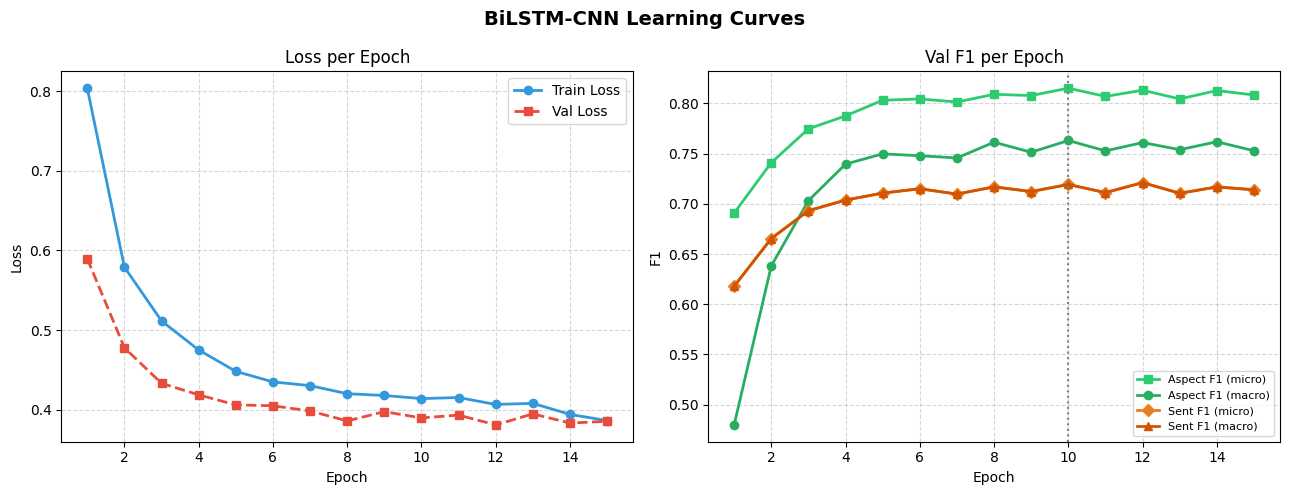

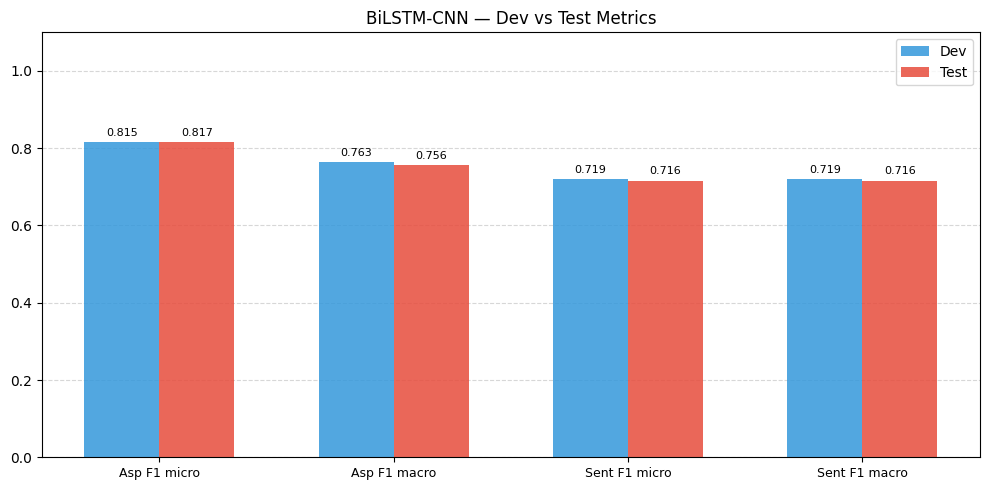

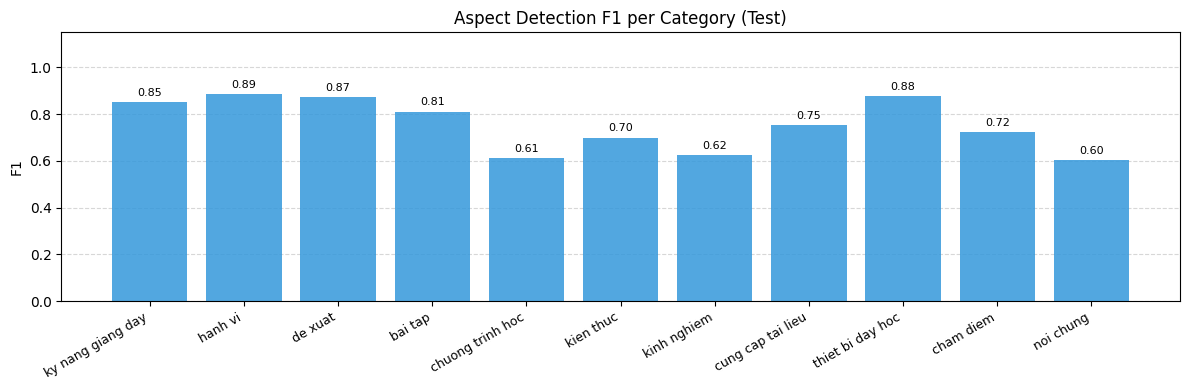

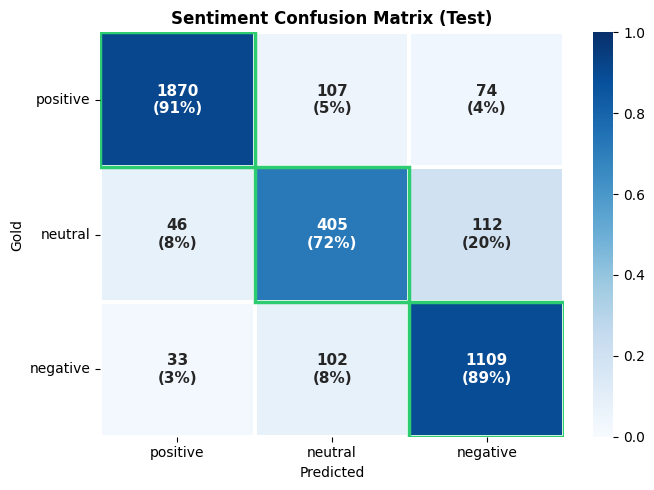

In [75]:
from sklearn.metrics import f1_score as sk_f1

# ── 1. Learning curves ────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('BiLSTM-CNN Learning Curves', fontsize=14, fontweight='bold')

epochs = history['epoch']
ax1.plot(epochs, history['train_loss'], 'o-', color='#3498db', label='Train Loss', lw=2)
ax1.plot(epochs, history['val_loss'],   's--', color='#e74c3c', label='Val Loss',   lw=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Loss per Epoch')
ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.5); ax1.set_axisbelow(True)

ax2.plot(epochs, history['val_asp_f1_micro'],   's-', color='#2ecc71', lw=2, label='Aspect F1 (micro)')
ax2.plot(epochs, history['val_asp_f1_macro'],   'o-', color='#27ae60', lw=2, label='Aspect F1 (macro)')
ax2.plot(epochs, history['val_sent_f1_micro'],  'D-', color='#e67e22', lw=2, label='Sent F1 (micro)')
ax2.plot(epochs, history['val_sent_f1_macro'],  '^-', color='#d35400', lw=2, label='Sent F1 (macro)')
best_epoch = epochs[history['val_asp_f1_micro'].index(max(history['val_asp_f1_micro']))]
ax2.axvline(best_epoch, color='gray', linestyle=':', lw=1.5)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('F1'); ax2.set_title('Val F1 per Epoch')
ax2.legend(fontsize=8); ax2.grid(True, linestyle='--', alpha=0.5); ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Dev vs Test bar chart ──────────────────────────────────────────────
metrics_compare = {
    'Asp F1 micro': (dev_metrics['asp_f1_micro'],  test_metrics['asp_f1_micro']),
    'Asp F1 macro': (dev_metrics['asp_f1_macro'],  test_metrics['asp_f1_macro']),
    'Sent F1 micro':(dev_metrics['sent_f1_micro'], test_metrics['sent_f1_micro']),
    'Sent F1 macro':(dev_metrics['sent_f1_macro'], test_metrics['sent_f1_macro']),
}
x = np.arange(len(metrics_compare)); width = 0.32
fig, ax = plt.subplots(figsize=(10, 5))
for i, (split, col) in enumerate([('Dev','#3498db'),('Test','#e74c3c')]):
    vals = [v[i] for v in metrics_compare.values()]
    bars = ax.bar(x + (i-0.5)*width, vals, width, label=split, color=col, alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=3)
ax.set_xticks(x); ax.set_xticklabels(list(metrics_compare.keys()), fontsize=9)
ax.set_ylim(0, 1.1); ax.set_title('BiLSTM-CNN — Dev vs Test Metrics')
ax.legend(); ax.yaxis.grid(True, linestyle='--', alpha=0.5); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

# ── 3. Per-category Aspect F1 (Test) ─────────────────────────────────────
all_gold = test_metrics['all_gold']
all_pred = test_metrics['all_pred']
per_cat_f1 = [
    sk_f1((all_gold[:,i]!=0).astype(int), (all_pred[:,i]!=0).astype(int), zero_division=0)
    for i in range(NUM_ASPECTS)
]
short_labels = [c.replace('_',' ') for c in ASPECT_CATEGORIES]
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(short_labels, per_cat_f1, color='#3498db', alpha=0.85)
ax.bar_label(bars, fmt='%.2f', fontsize=8, padding=3)
ax.set_ylim(0, 1.15); ax.set_ylabel('F1')
ax.set_title('Aspect Detection F1 per Category (Test)')
ax.yaxis.grid(True, linestyle='--', alpha=0.5); ax.set_axisbelow(True)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout(); plt.show()

# ── 4. Sentiment confusion matrix (Test, bỏ none) ────────────────────────
cm      = confusion_matrix(test_metrics['sent_gold'], test_metrics['sent_pred'], labels=[1,2,3])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
annots  = np.array([[f'{cm[i,j]}\n({cm_norm[i,j]:.0%})' for j in range(3)] for i in range(3)])
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_norm, annot=annots, fmt='', cmap='Blues', ax=ax,
            xticklabels=['positive','neutral','negative'],
            yticklabels=['positive','neutral','negative'],
            vmin=0, vmax=1, linewidths=1.5, linecolor='white',
            annot_kws={'size':11,'weight':'bold'})
for i in range(3):
    ax.add_patch(plt.Rectangle((i,i),1,1,fill=False,edgecolor='#2ecc71',lw=2.5))
ax.set_title('Sentiment Confusion Matrix (Test)', fontsize=12, fontweight='bold')
ax.set_ylabel('Gold'); ax.set_xlabel('Predicted')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout(); plt.show()


## 10. Inference

In [76]:
def predict(text, model, word2idx, threshold_none=0.5):
    """
    Predict aspects và sentiment cho 1 câu.
    threshold_none: nếu max_prob(non-none) < threshold thì bỏ qua aspect đó.
    """
    model.eval()
    tokens = preprocess_text(text).split()
    unk    = word2idx.get('<UNK>', 1)
    pad    = word2idx.get('<PAD>', 0)
    ids    = [word2idx.get(t, unk) for t in tokens][:MAX_SEQ_LENGTH]
    ids    = ids + [pad] * (MAX_SEQ_LENGTH - len(ids))

    with torch.no_grad():
        input_ids = torch.tensor([ids], dtype=torch.long).to(device)
        _, logits = model(input_ids)                          # (1, 11, 4)
        probs     = F.softmax(logits, dim=-1).squeeze(0)      # (11, 4)
        pred      = logits.argmax(dim=-1).squeeze(0).cpu()    # (11,)

    results = []
    for i, cat in enumerate(ASPECT_CATEGORIES):
        label_id = pred[i].item()
        if label_id == 0:
            continue
        confidence = probs[i, label_id].item()
        results.append({
            'category':   cat,
            'sentiment':  ID2LABEL[label_id],
            'confidence': round(confidence, 3),
        })
    return results


test_sentences = [
    'Thầy dạy rất hay nhưng phòng học quá nóng.',
    'Giảng viên nhiệt tình, tài liệu đầy đủ.',
    'Bài kiểm tra quá khó và không công bằng.',
]
for sent in test_sentences:
    result = predict(sent, model, word2idx)
    print(f'Input : {sent}')
    for r in result:
        print(f'  → [{r["category"]}] {r["sentiment"]} (conf={r["confidence"]})')
    print()


Input : Thầy dạy rất hay nhưng phòng học quá nóng.
  → [ky_nang_giang_day] negative (conf=0.464)
  → [thiet_bi_day_hoc] negative (conf=0.596)

Input : Giảng viên nhiệt tình, tài liệu đầy đủ.
  → [hanh_vi] positive (conf=0.964)
  → [cung_cap_tai_lieu] positive (conf=0.983)

Input : Bài kiểm tra quá khó và không công bằng.
  → [bai_tap] negative (conf=0.9)
  → [cham_diem] negative (conf=0.864)

